2.109624429902566
64.58547838098232
[0.42014187225573346, 0.05765700567865961, 0.043486506084363996, 0.04129924472945993]
[0. 0. 0. 0. 0.]
1.1882513995257729


C:\Users\slok0019\AppData\Local\Temp\ipykernel_33524\697353410.py:130: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  force_at_time_t[i] = calcPedForce(Human,t[i])


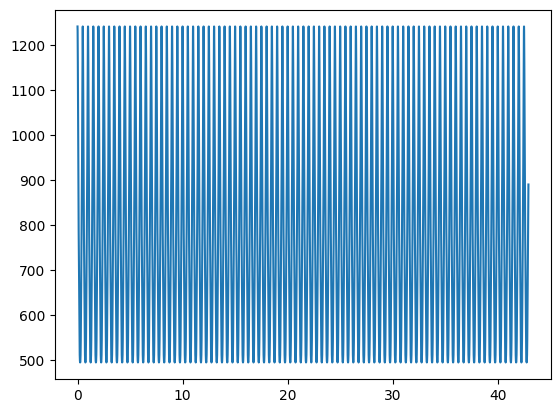

In [2]:
import math
import numpy as np
import random
from matplotlib import pyplot as plt
from pedestrian import *
from scipy.signal import welch
from solver import Phi_matrix,accdyn_super
from matrix import bridge

length = 50  # L - Length (m)
width = 2  # b - Width (m)
height = 0.6  # h - Height (m)
E = 200e9  # E - Young's modulus (N/m^2)
modalDampingRatio = 0.005  # xi - Modal damping ratio of the beam
nHigh = 3  # nHigh - Higher mode for damping matrix
beamFreq =2 #Hz
area = 0.3162  # A - Cross-section area (m^2)
linearMass = 500  # m - Linear mass (kg/m)
x_interested= length/2
numbers = 3

#ped
numped = 1
pedmass = 80     #kg
peddamp = .3    
#pedstiff = 25000 #N/m
pedpace  = 2     #Hz
pedphase = 0
pedInlocation = 0
pedvelocity = 1.25
pedBodyF= 2 #Hz

#ped
kped=(2*np.pi*pedBodyF)**2*pedmass
cped = (2*np.pi*pedBodyF)*2*peddamp*pedmass

modulus =linearMass * ((2 * math.pi * beamFreq) * (math.pi / length) ** (-2)) ** 2  #E*(width*height**3)/12

#set time info
hht=0.01

#initial possition vector.......formultiple ped all these would become matrices

#xrb=np.zeros(1,numped)
xrb=[0]

Bridge = bridge(   
    length = length,                 # m
    modulus = modulus,               # N m^2
    density = linearMass,            # kg/m
    damp    = modalDampingRatio ,    #%
    numbers = 3,  )                   #modes


N_bridge = 4

# probabilitstic parameters
mean_pace = 2 #Hz  2005 pachi
pace_COV = 0.1

mean_mass= 70 #kg
mass_COV= 0.17 #from butz 2008

mean_velocity = 1.3
std_velocity = 0.12 #pachi 2005

mean_alpha = np.array([0.41 * (mean_pace - 0.95),
                0.069 + 0.0056 * mean_pace,
                .033 + 0.0064 * mean_pace,
                0.013 + 0.0065 *mean_pace])

alpha_COV= np.array([0.17,0.4,0.4,0.4])


alpha_std = mean_alpha*alpha_COV

# Generate a random variable from a normal distribution with considered mean and std_dev from literiture

randomPace = random.gauss(mean_pace, pace_COV*mean_pace)
randomMass = random.gauss(mean_mass, mass_COV*mean_mass)
randomAlpha = [random.gauss(mean_alpha[i], alpha_std[i]) for i in range(len(alpha_COV))]
#randomPhase = [random.uniform(0, 2 * math.pi) for i in range(len(mean_alpha)+1)]
randomVelocity = random.gauss(mean_velocity,std_velocity)
randomPhase = np.zeros(5)


print(randomPace)
print(randomMass)
print(randomAlpha)
print(randomPhase)
print(randomVelocity)

t = np.array(np.arange(0, (length + 1) / randomVelocity, hht))

Human = Pedestrian(
         mass = pedmass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = pedpace ,    #Hz
         phase = pedphase,
         location = pedInlocation,
         velocity = pedvelocity,
         
        iSync=0)
'''
Human = Pedestrian(
         mass = randomMass,     #kg
         damp = peddamp ,   #%
         stiff = kped, #N/m
         pace  = randomPace ,    #Hz
         phase = randomPhase,
         location = pedInlocation,
         velocity = randomVelocity,
         
         iSync=0)'''

#ped = RandPedestrian(randomMass, randomPace, randomPhase, randomAlpha)
n=1
numped=1
#j=np.size(t)
xr=[0]
force_at_time_t = np.zeros(np.size(t))


#modal force
individualforce= np.zeros(np.size(t))
F=np.zeros((N_bridge,np.size(t)))
for i in range (np.size(t)):
     
    force_at_time_t[i] = calcPedForce(Human,t[i])
    #print(force_at_time_t)
    NN=Phi_matrix(xr,length,linearMass,4,numped)
    #print(NN)
    F[:,[i]] = NN * force_at_time_t[i]  #modalforce
    xr=np.add(xr,randomVelocity*hht)

plt.plot(t,force_at_time_t)


In [ ]:
def modal_force(t, x, F0, omega, L, n):
    F_n = np.zeros_like(t)
    NN=Phi_matrix(xr,length,linearMass,4,numped)
    
    for i in range(len(t)):
        f_xt = external_force(x, t[i], F0, omega)
        F_n[i] = np.trapz(f_xt * phi_n, x)  # Numerical integration over the length of the beam
    
    return F_n